# Models used for prediction

## Yield prediction model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("yield_dataset/crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
df["Fertilizer_Used"] = df["Fertilizer_Used"].astype(int)
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,True,Cloudy,110,7.248251


In [4]:
df["Irrigation_Used"] = df["Irrigation_Used"].astype(int)
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


In [5]:
df.shape

(1000000, 10)

In [6]:
df.drop(df[df['Crop'] == 'Barley'].index, inplace=True)
df.shape

(833223, 10)

In [7]:
df["Crop"].unique()

array(['Cotton', 'Rice', 'Soybean', 'Wheat', 'Maize'], dtype=object)

In [8]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

No null values

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(833223, 10)

No duplicates

### Target feature encoding

In [11]:
crop_mean = df.groupby('Crop')['Yield_tons_per_hectare'].mean().to_dict()
region_mean = df.groupby('Region')['Yield_tons_per_hectare'].mean().to_dict()
soil_mean = df.groupby('Soil_Type')['Yield_tons_per_hectare'].mean().to_dict()
weather_mean = df.groupby('Weather_Condition')['Yield_tons_per_hectare'].mean().to_dict()

df['Crop'] = df['Crop'].map(df.groupby('Crop')['Yield_tons_per_hectare'].mean())
df['Region'] = df['Region'].map(df.groupby('Region')['Yield_tons_per_hectare'].mean())
df['Soil_Type'] = df['Soil_Type'].map(df.groupby('Soil_Type')['Yield_tons_per_hectare'].mean())
df['Weather_Condition'] = df['Weather_Condition'].map(df.groupby('Weather_Condition')['Yield_tons_per_hectare'].mean())

df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,4.651782,4.646436,4.650841,897.077239,27.676966,0,1,4.645800,122,6.555816
1,4.649300,4.643511,4.650760,992.673282,18.026142,1,1,4.653425,140,8.527341
3,4.653231,4.646436,4.653712,986.866331,16.644190,0,1,4.653425,146,6.517573
4,4.649300,4.651967,4.652740,730.379174,31.620687,1,1,4.645800,110,7.248251
5,4.649300,4.651967,4.653712,797.471182,37.704974,0,1,4.653425,74,5.898416


<Axes: >

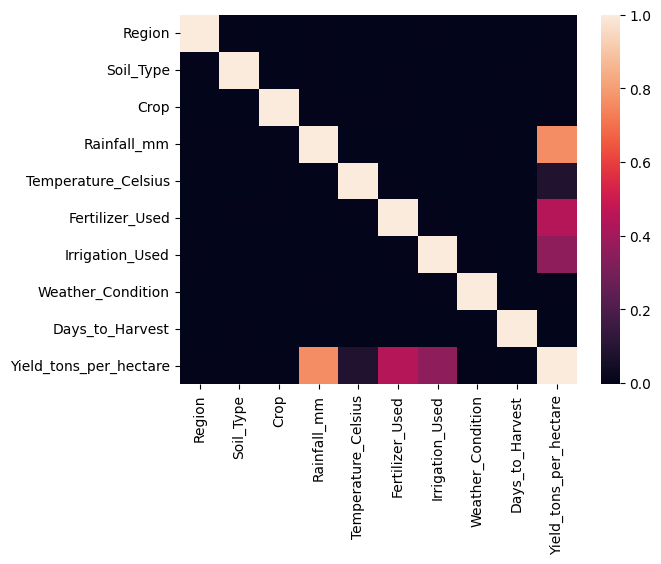

In [12]:
sns.heatmap(df.corr())

Dropping 'Days_to_Harvest', 'Soil_Type', 'crop , 'Region' and 'Weather_Condition'

In [13]:
columns_to_drop = ['Days_to_Harvest', 'Soil_Type', 'Region', 'Weather_Condition', 'Crop']
df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [14]:
df.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare
0,897.077239,27.676966,0,1,6.555816
1,992.673282,18.026142,1,1,8.527341
3,986.866331,16.644190,0,1,6.517573
4,730.379174,31.620687,1,1,7.248251
5,797.471182,37.704974,0,1,5.898416


<Axes: >

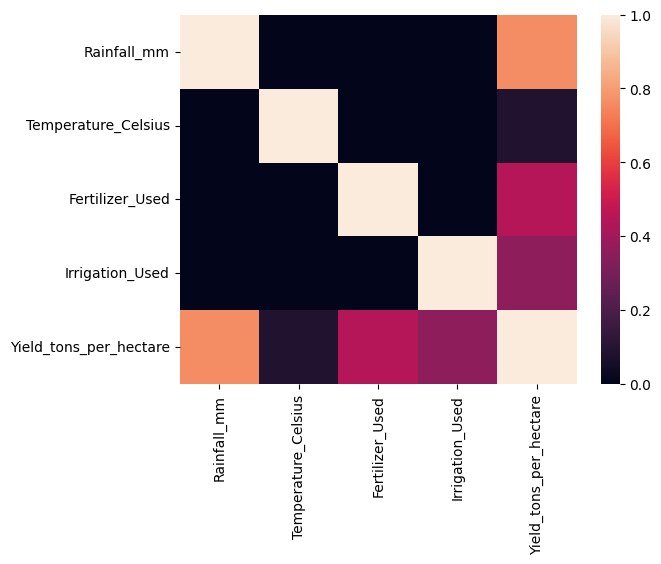

In [15]:
sns.heatmap(df.corr())

In [16]:
X, y = df.iloc[:,:-1], df["Yield_tons_per_hectare"]
X, y

(        Rainfall_mm  Temperature_Celsius  Fertilizer_Used  Irrigation_Used
 0        897.077239            27.676966                0                1
 1        992.673282            18.026142                1                1
 3        986.866331            16.644190                0                1
 4        730.379174            31.620687                1                1
 5        797.471182            37.704974                0                1
 ...             ...                  ...              ...              ...
 999994   167.459161            22.153946                0                1
 999995   302.805345            27.987428                0                0
 999997   867.362046            24.370042                1                0
 999998   492.812857            33.045505                0                0
 999999   180.936180            27.298847                1                0
 
 [833223 rows x 4 columns],
 0         6.555816
 1         8.527341
 3         6.51757

In [17]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare
count,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000
mean,550.066118,27.505781,0.500076,0.499488,4.649885
std,259.868267,7.221124,0.500000,0.500000,1.696228
min,100.005750,15.000068,0.000000,0.000000,-1.147613
25%,325.059847,21.253312,0.000000,0.000000,3.419927
50%,550.188354,27.512674,1.000000,0.000000,4.652047
75%,774.853691,33.749848,1.000000,1.000000,5.878641
max,999.998098,39.999997,1.000000,1.000000,9.963372


### Modelling

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def measure(y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"""
r2 = {r2}
mse = {mse}
mae = {mae}
""")

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_features = X_train.columns
X_features

Index(['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
       'Irrigation_Used'],
      dtype='object')

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 1.35116944, -1.16477231, -0.99990399,  1.00148931],
       [ 0.53702383, -1.72395967, -0.99990399, -0.99851291],
       [ 1.47352071, -1.12006797, -0.99990399, -0.99851291],
       ...,
       [-0.91396321, -0.83037232,  1.00009602, -0.99851291],
       [ 1.04140164, -0.01046043,  1.00009602,  1.00148931],
       [-1.57221976,  0.73573964, -0.99990399,  1.00148931]],
      shape=(666578, 4))

In [32]:
scaler.get_feature_names_out()

array(['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
       'Irrigation_Used'], dtype=object)

### Linear Regression

In [22]:
from sklearn.linear_model import LinearRegression
Linear_regr = LinearRegression()

Linear_regr.fit(X_train_scaled,y_train)
y_pred = Linear_regr.predict(scaler.transform(X_test))

score = Linear_regr.score(scaler.transform(X_test),y_test)
print(f"score = {score}")
measure(y_test, y_pred)


score = 0.9132299872723852

r2 = 0.9132299872723852
mse = 0.24971461334844564
mae = 0.3985285240160069



### Stoichastic Gradient Descent Regression

In [23]:
from sklearn.linear_model import SGDRegressor
SGD_regr = SGDRegressor()

SGD_regr.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)
y_pred = SGD_regr.predict(X_test_scaled)

print(f"score = {SGD_regr.score(X_test_scaled, y_test)}")
measure(y_test,y_pred)

score = 0.913187045981826

r2 = 0.913187045981826
mse = 0.24983819368952875
mae = 0.3986478326632138



### Gradient Boosting

In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor
GB_regr = HistGradientBoostingRegressor()

GB_regr.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)
y_pred = GB_regr.predict(X_test_scaled)

print(f"score = {GB_regr.score(X_test_scaled, y_test)}")
measure(y_test,y_pred)

score = 0.9130304145797371

r2 = 0.9130304145797371
mse = 0.2502889617461574
mae = 0.39897957950777313



### Best models are
- Linear Regression
- SGD Regression
- Gradient Boosting Regression

In [25]:
def regression_plots(model, X_test, y_test):
    """
    Generates prediction vs actual and residual plots for any regression model.
    
    Parameters:
        model  : Trained regression model with a .predict() method
        X_test : Test feature data
        y_test : True target values
    """

    # Predictions
    y_pred = model.predict(X_test)

    # --- Plot 1: Prediction vs Actual ---
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label="Ideal Fit")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot 2: Residual Plot ---
    residuals = y_test - y_pred

    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.grid(True)
    plt.show()

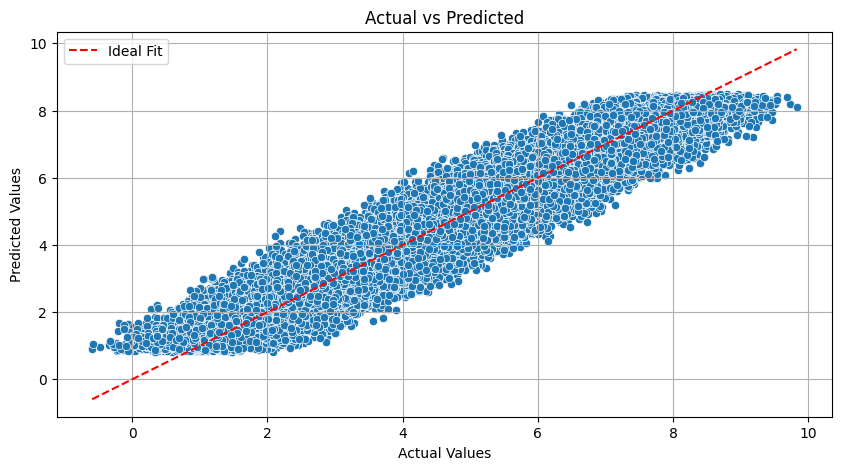

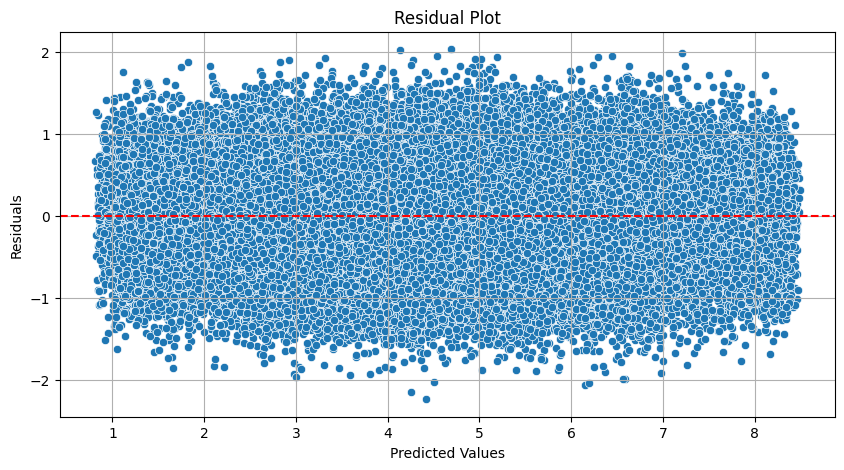

In [26]:
regression_plots(Linear_regr, X_test_scaled, y_test)

## Pipeline

In [27]:
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('scaler', scaler),
    ('regressor', Linear_regr)
])

y_pred_pipeline = model.predict(X_test)
measure(y_test,y_pred_pipeline)


r2 = 0.9132299872723852
mse = 0.24971461334844564
mae = 0.3985285240160069



In [41]:
model.predict(pd.DataFrame({'Rainfall_mm' : [150], 
                            'Temperature_Celsius' : [30], 
                            'Fertilizer_Used' : [1], 
                            'Irrigation_Used' : [1]
                            }))

array([4.05085392])

# Saving Model

In [44]:
import joblib

joblib.dump(model, "model.joblib")


['model.joblib']